Dataset for Students Performance for High School Students 

# Academic Success Factors in High School Students 

The dataset includes information on 2,932 high school students and their performance success (GPA), collected and shared by Rabie El Kharoua, as well as possible affecting factors such as gender, ehtnicity, time spent (in hours) studying in a week, abscences, tutoring and other extracurricular activities that might or might not have any correlation with the students performance success.

We don't know geographical association with this data and whether it presents results applicable only to a sample of population of a certain geographical location or can be extended onto the whole population of high school students.

# OBJECTIVE
The goal of this project is to analyze what factors influence the student performance (GPA) and find relatinships between demographic and behavioral variables such as age, gender, study time and GPA.

Key Research Questions

1) What is the proportion of female to male high school students?
2) Does GPA differ across age groups (15-18)?
3) Is there a significant GPA difference between males and females?
4) Does weekly study time influence GPA?
5) Which factors have the strongest correlation with GPA?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from scipy.stats import f_oneway
from scipy.stats import shapiro
import seaborn as sns

df = pd.read_csv(r"/Users/daria/Desktop/Data-Analysis-Portfolio/academic_performance_data_analysis/data.csv") 

print(df.shape)

df.head(30)

(2392, 15)


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0
5,1006,18,0,0,1,8.191219,0,0,1,1,0,0,0,3.084184,1.0
6,1007,15,0,1,1,15.601680,10,0,3,0,1,0,0,2.748237,2.0
7,1008,15,1,1,4,15.424496,22,1,1,1,0,0,0,1.360143,4.0
8,1009,17,0,0,0,4.562008,1,0,2,0,1,0,1,2.896819,2.0
9,1010,16,1,0,1,18.444466,0,0,3,1,0,0,0,3.573474,0.0


# STEP 1: CLEANING DATA
Let's clean the dataset from empty values, duplicates and etc.

SUMMARY: Our dataset is quite clean, so there is not much we can do to make it better. One possible alteration to add is to get rid of student IDs as they are repetetive of the index numbers and don't hold any special value or meaning.

In [2]:
df = df.drop_duplicates()
# df = df.drop("StudentID", axis=1) 
df

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2387,3388,18,1,0,3,10.680555,2,0,4,1,0,0,0,3.455509,0.0
2388,3389,17,0,0,1,7.583217,4,1,4,0,1,0,0,3.279150,4.0
2389,3390,16,1,0,2,6.805500,20,0,2,0,0,0,1,1.142333,2.0
2390,3391,16,1,1,0,12.416653,17,0,2,0,1,1,0,1.803297,1.0


CHECKING FOR EMPTY VALUES

In [3]:
df.isna() # for checking missing data
df.isna().sum() # no missing values in the data

StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

No missing values were detected. Duplicate records were removed.

# STEP 2: DESCRIPTIVE STATISTICS
Let's group and analyse our data according to categorical data and quantative data, calculate frequency tables and draw distribution graphs.

# CATEGORICAL DATA

Our categorical data consists of:

1. Age (15 - 18 years)
2. Gender (where 0 - male, 1 - female)
3. Ethnicity (where 0 - Caucasian, 1 - African American, 2 - Asian, 3 - Other)
4. Tutoring (0 - no tutoring, 1 - tutoring)

Others factors can be observed if the heatmap shows any significant correlation between them and GPA


# Age Distribution 

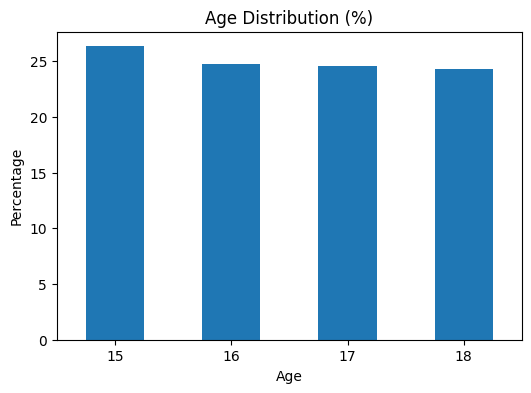

In [4]:
# ages=pd.crosstab(index=df["Age"]),
#             columns="count")
# ages["CumulativeFrequency"] = ages.cumsum()
# ages a way of creating a table with frequency counts

freq = df["Age"].value_counts()
percent = df["Age"].value_counts(normalize=True) * 100


percent.plot(kind="bar", figsize=(6,4))
plt.title("Age Distribution (%)")
plt.xlabel("Age")
plt.ylabel("Percentage")
plt.xticks(rotation=0)

plt.show()

In [5]:
freq_table = pd.DataFrame({
    "Count": freq,
    "Percent": percent.round(1)
})

freq_table

,Count,Percent
Age,,
15,630,26.3
16,593,24.8
17,587,24.5
18,582,24.3


Age Distribution shows that the sample is represented evenly by ages 16, 17 and 18 with 15 year olds being the majority in the sample, amounting to 630 students (26.3%)

# Gender Distribution 

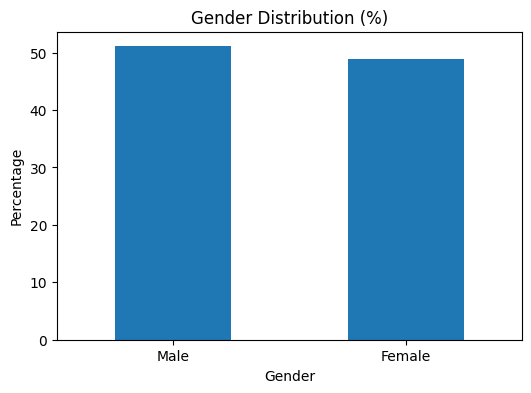

In [6]:
freq_1 = df["Gender"].value_counts()
percent_1 = df["Gender"].value_counts(normalize=True) * 100

percent_1.plot(kind="bar", figsize=(6,4))
plt.title("Gender Distribution (%)")
plt.xlabel("Gender")
plt.ylabel("Percentage")
plt.xticks(
    ticks=[0,1],
    labels=["Male", "Female"],
    rotation=0)

plt.show()

In [7]:
freq_table_1 = pd.DataFrame({
    "Count": freq_1,
    "Percent": percent_1.round(1)
})

freq_table_1

,Count,Percent
Gender,,
1,1222,51.1
0,1170,48.9


Gender Distibution shows pretty equal distribution across two genders, with females comprising the majority (51$) of the sample - which speaks to the general assumptions on the existing proportions between males and females.

# QUANTATIVE DATA

# GPA Distribution

Frequency Table Summary

In [8]:
# no rounding variables in the original column of the dataset
freq_2 = df["GPA"].value_counts()

percent_2 = df["GPA"].value_counts(normalize=True) * 100
percent_2 = percent_2.round(1)

freq_table_2 = pd.DataFrame({
    "Count": freq_2,
    "Percent": percent_2
})

freq_table_2 = freq_table_2.sort_index()
freq_table_2


,Count,Percent
GPA,,
0.000000,16,0.7
0.012063,1,0.0
0.019798,1,0.0
0.021156,1,0.0
0.026469,1,0.0
...,...,...
3.947093,1,0.0
3.951460,1,0.0
3.979421,1,0.0


Numerical or 5 number summary

In [9]:
df["GPA"].describe()


count    2392.000000
mean        1.906186
std         0.915156
min         0.000000
25%         1.174803
50%         1.893393
75%         2.622216
max         4.000000
Name: GPA, dtype: float64

In [10]:
df["GPA"].skew()

np.float64(0.014525601346976225)

Distribution is very slightly positively skewed (0,01)

Histogram - GPA Distribution

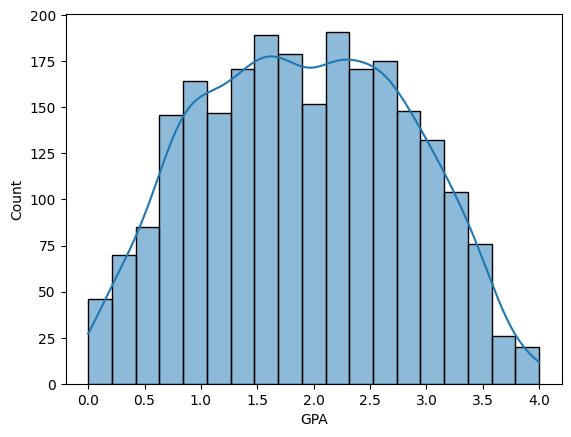

In [11]:
sns.histplot(df["GPA"], kde=True) # grades are a bit scewed on the right
plt.show()

# GPA SUMMARY

The numerical summary shows that the GPA mean (1.91) and median (2) are almost the same, the distribution is unimodal and its graph is bell-shaped which implies GPA distribution is normal and empirical rule can be applied. 

We are seeing that the average GPA score for 2392 observed high-school students is 2.0, which means 35% of students of ages 15-18 have a 2.0 GPA. 

We can also observe that GPAs ranging from 1.1 to 2.9 make up 68% of GPA across high-schoolers. We can also see that even though  GPA 2.0 is the average, there are more students with GPA 1.5 and GPAs [1.5; 2.5]

GPA Distribution seems to be normal with a mean (1.9) and standard deviation (0.9).

# STUDY TIME WEEKLY Distribution

Frequency Table

In [12]:
freq_4 = df["StudyTimeWeekly"].value_counts()

percent_4 = df["StudyTimeWeekly"].value_counts(normalize=True) * 100
percent_4 = percent_4.round(1)

freq_table_4 = pd.DataFrame({
    "Count": freq_4,
    "Percent": percent_4
})

freq_table_4 = freq_table_4.sort_index()
freq_table_4


,Count,Percent
StudyTimeWeekly,,
0.001057,1,0.0
0.004859,1,0.0
0.008031,1,0.0
0.008206,1,0.0
0.014337,1,0.0
...,...,...
19.939810,1,0.0
19.948459,1,0.0
19.968425,1,0.0


Numerical Summary

In [13]:
df["StudyTimeWeekly"].describe()

count    2392.000000
mean        9.771992
std         5.652774
min         0.001057
25%         5.043079
50%         9.705363
75%        14.408410
max        19.978094
Name: StudyTimeWeekly, dtype: float64

Study Time Weekly Distribution Histogram

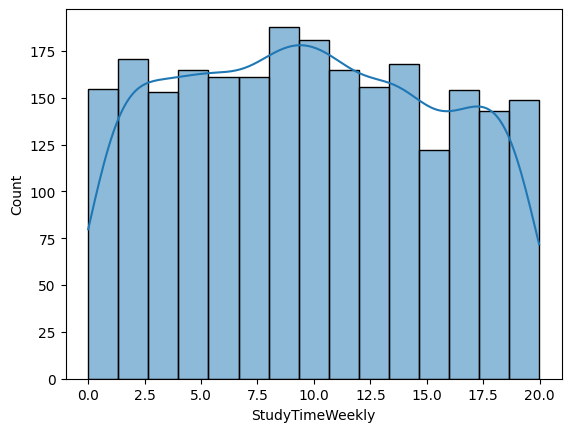

In [14]:
sns.histplot(df["StudyTimeWeekly"], kde=True) 
plt.show()

# STUDY TIME WEEKLY SUMMARY

The numerical summary shows that the Study Time Weekly  mean (9.7 hours) and median (9.7 hours) are the same, the distribution is unimodal and its graph is bell-shaped without a sizeable peak and spread out variance, which implies Study Time Weekly distribution is normal and empirical rule can be applied. 

We are seeing that the average Study Time spent in hours weekly for 2392 observed high-school students is 9.7 hours.

Study Time Weekly Distribution seems to be normal with a mean (9.7) and standard deviation (5.6).

# STEP 3: CORRELATION BETWEEN GPA AND STUDY TIME WEEKLY

Let's explore relationships between GPA and Study Time Weekly by plotting the two variables on a scatterplot and look for any dependence. 

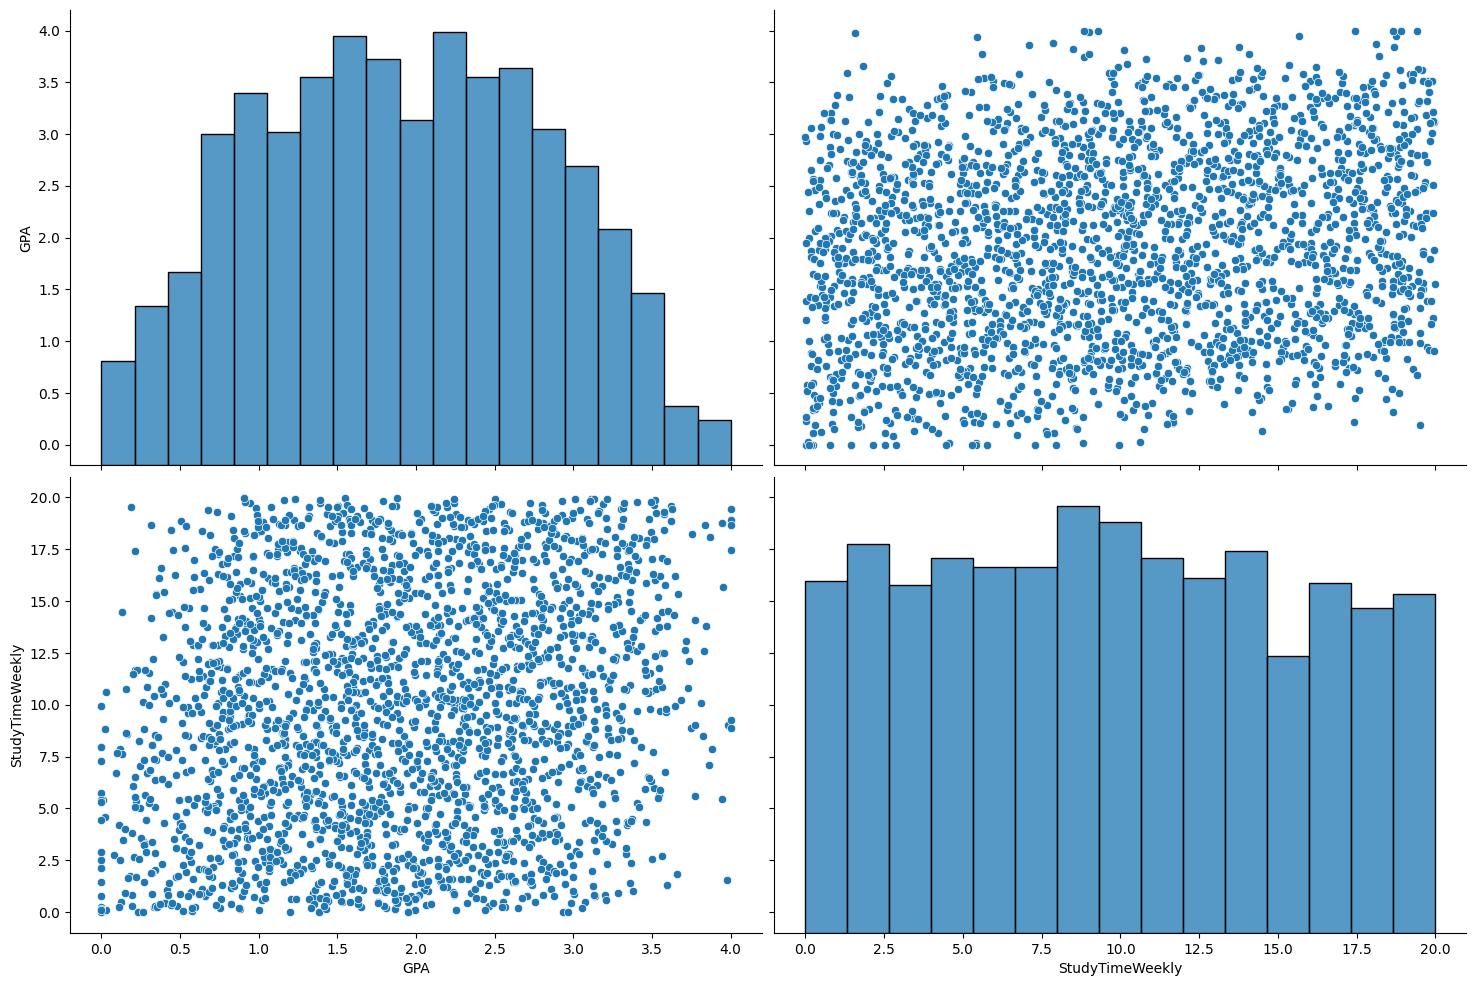

In [16]:
sns.pairplot(df[["GPA", "StudyTimeWeekly"]], height=5, aspect=1.5)
plt.show()

So far, the graphs show no significant relationship between the two, which we will further explore by calculating correlation coefficients for the variables in step 5.

# STEP 4: GPA ACROSS AGE GROUPS AND GENDER
Let's create multivariate boxplots for age and gender groups. 

This will help us observe tendencies of GPA distribution.

In [17]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[15, 16, 17, 18, 19],
    labels=["15", "16", "17", "18"],
    right=False
)


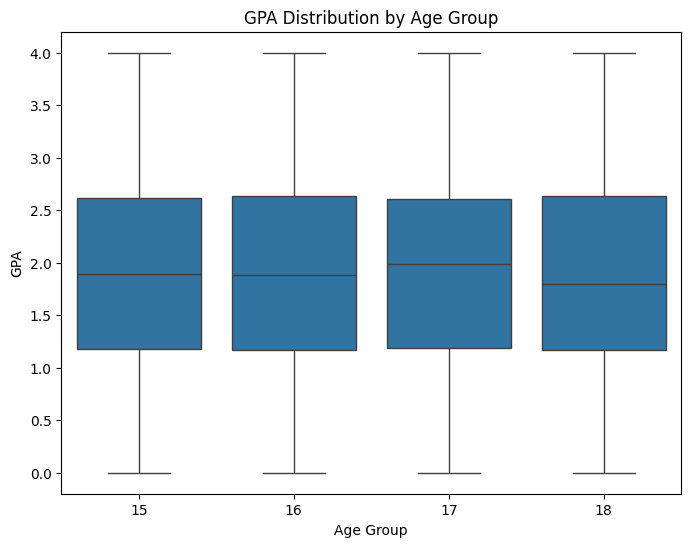

In [18]:
plt.figure(figsize=(8,6))

sns.boxplot(x="AgeGroup", y="GPA", data=df)

plt.title("GPA Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("GPA")

plt.show()

The boxplots across age groups show that graphically there is no difference between GPA averages among students 15 and 16 years old (just below 2.0). However there is a difference between medians for ages 17 (highest across all) and 18 (lowest among all).

Now let's statistically test whether the difference observed in the graph is a statistically significant difference between age GPA means by using ANOVA Test.

Let H0: Mean GPA is equal across age groups

H1: At least one age group differs


In [19]:
groups = [group["GPA"].values for name, group in df.groupby("AgeGroup")]
f_stat, p_value = f_oneway(*groups)

print("p-value", p_value)

p-value 0.9216214667783363


/var/folders/7b/b57c6st93qb8h1l7b39319j80000gn/T/ipykernel_29638/994770963.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [group["GPA"].values for name, group in df.groupby("AgeGroup")]


Since p-value = 0.9, we are not rejecting H0 hypothesis and can assume that there isn't a statiscally significant difference among age groups.

However we also know that GPA distribution is slightly positively skewed and there is a slight difference between medians and means but if the assumption of normality continues to hold true for GPA statistically then we can assume that there is no significant difference between groups. 
I'll check the normality using Shapiro-Wilk Test

H0: normal distribution
H1: not normal

In [20]:
stat, p = shapiro(df["GPA"])

print("Statistic:", stat)
print("p-value", p)

Statistic: 0.9838187150154397
p-value 7.294327280605808e-16


According to the test, GPA is normally distributed (p-value is really big) therefore we assume correctness of no statistical significance for two groups. 

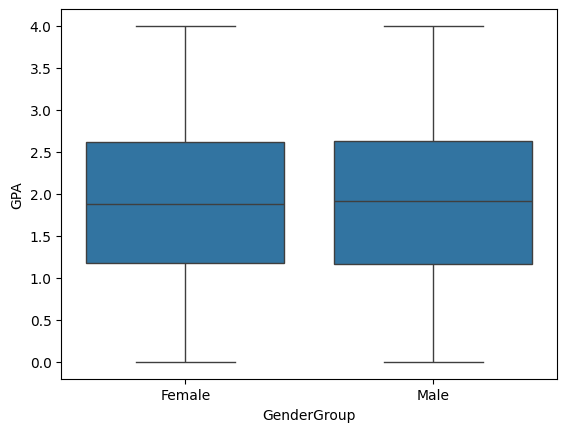

In [21]:
df["GenderGroup"] = df["Gender"].map({0: "Male", 1: "Female"})

sns.boxplot(x="GenderGroup", y="GPA", data=df)
plt.show()


The graph seems to show that there is no visual difference between GPA means across genders.

That's why let's do statistical tests to see if there is a difference between GPA across genders.



In [22]:
males = df[df["GenderGroup"] == "Male"] ["GPA"]
females = df[df["GenderGroup"] == "Female"] ["GPA"]

t_stat, p_value = ttest_ind(males, females, equal_var=False)

print("p-value", p_value)

p-value 0.5136676190960221


Since p-value = 0.5, we are not rejecting H0 hypothesis and can assume that there isn't a statiscally significant GPA difference at 5% among genders.

# CONCLUSION 

Age and Gender don't have enough impact on GPA to be considered significant factors. And there are no statistically significant differences in GPA across age and gender groups.

# STEP 5: FINDING CORRELATION BETWEEN VARIABLES

Trying to find correlations between variables

In [23]:
df.columns
df_corr=df[[ 'Age', 'Gender', 'Ethnicity', 'ParentalEducation',
       'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport',
       'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA',
       'GradeClass']].corr()
df_corr

,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
Age,1.000000,0.044895,-0.028473,0.025099,-0.006800,-0.011511,-0.012076,0.033197,-0.025061,-0.046320,-0.003492,0.013074,0.000275,-0.006250
Gender,0.044895,1.000000,0.016010,0.006771,0.011469,0.021479,-0.031597,0.008065,-0.005964,-0.008897,0.007109,-0.000200,-0.013360,0.022998
Ethnicity,-0.028473,0.016010,1.000000,0.033595,0.007184,-0.025712,-0.017440,0.020922,-0.008927,-0.004484,-0.014627,0.013468,0.027760,-0.023326
ParentalEducation,0.025099,0.006771,0.033595,1.000000,-0.011051,0.036518,-0.017340,-0.017463,0.007479,0.002029,0.039439,0.011960,-0.035854,0.041031
StudyTimeWeekly,-0.006800,0.011469,0.007184,-0.011051,1.000000,0.009326,0.028930,0.035800,-0.022860,0.006836,0.007791,-0.016604,0.179275,-0.134131
Absences,-0.011511,0.021479,-0.025712,0.036518,0.009326,1.000000,-0.015534,0.002108,0.000360,0.041454,-0.008692,-0.018528,-0.919314,0.728633
Tutoring,-0.012076,-0.031597,-0.017440,-0.017340,0.028930,-0.015534,1.000000,-0.000824,0.004865,0.006278,-0.011385,-0.050898,0.145119,-0.111695
ParentalSupport,0.033197,0.008065,0.020922,-0.017463,0.035800,0.002108,-0.000824,1.000000,-0.008381,-0.006176,0.035122,-0.006036,0.190774,-0.136823
Extracurricular,-0.025061,-0.005964,-0.008927,0.007479,-0.022860,0.000360,0.004865,-0.008381,1.000000,-0.011820,-0.014191,-0.007427,0.094078,-0.069733
Sports,-0.046320,-0.008897,-0.004484,0.002029,0.006836,0.041454,0.006278,-0.006176,-0.011820,1.000000,-0.020474,-0.002799,0.057859,-0.026654


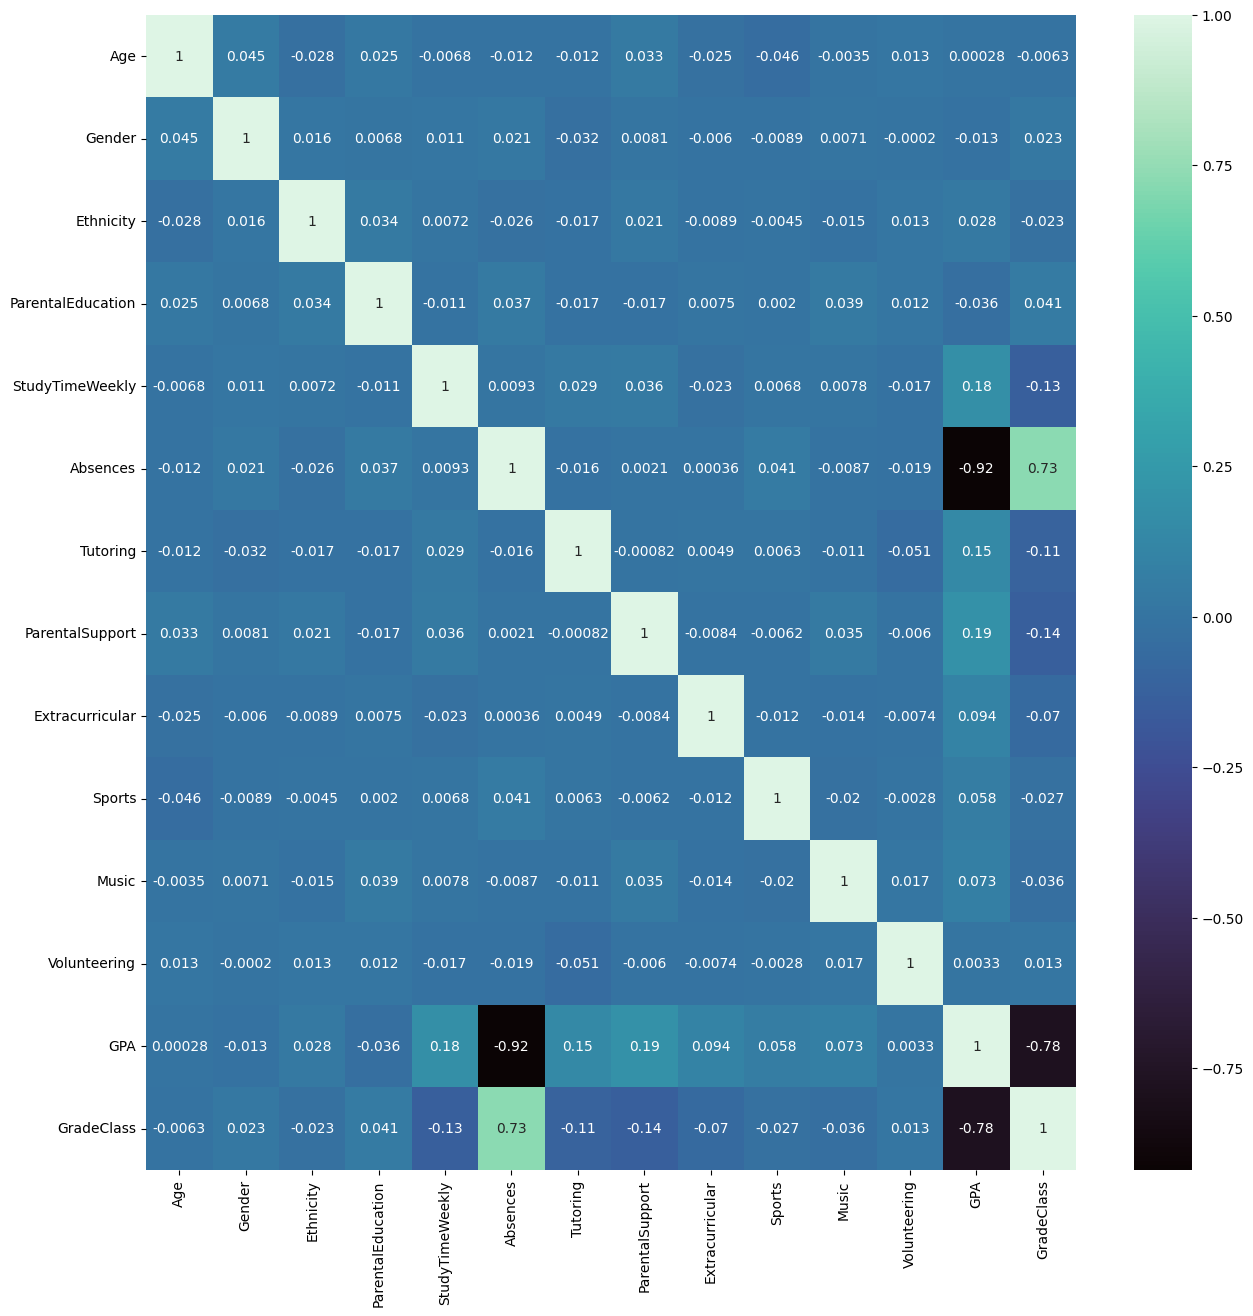

In [24]:
fig, ax = plt.subplots(figsize=(15,15))
sns.heatmap(df_corr, annot=True, cmap="mako")
plt.show()

Even though our heatmap includes categorical data it's important to remember that pearson coeffients only work and show correlation for continuous numerical data which is why making any assumptions about GPA and categorical data like age, gender, etc. wouldn't be right. 

In addition, the heatmap seems to imply only one significant correlation between GPA and abscences which is why we are going to explore the relationship further with the graphs. And as we can see correlation between GPA and Study Time Weekly is visible but very weak.

Relationship between GPA scores and absences

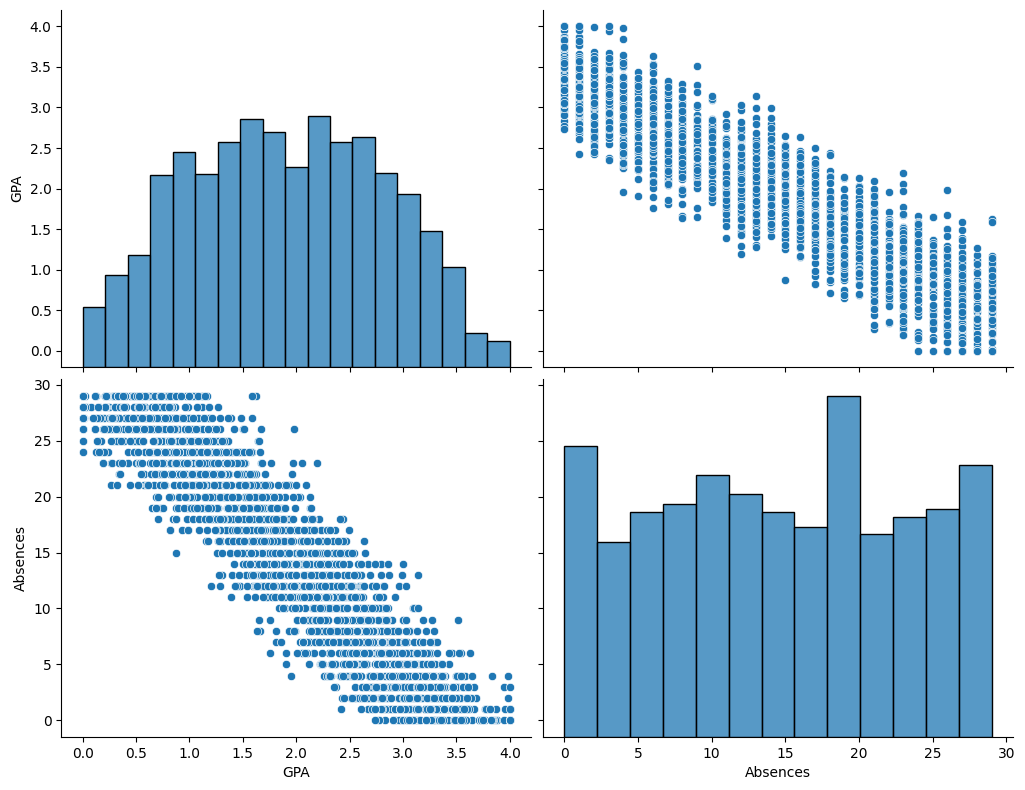

In [25]:
sns.pairplot(df[["GPA", "Absences"]], height=4, aspect=1.3)
plt.show()

We can infer a strong linear correlation both through pearson coefficient calculation and created graphs which means that fewer absences are strongly associeted with higher scores of GPA and more absences - with lower scores of GPA. However, we can't confidently say that fewer absences cause higher scores of GPA and vice versa.

# FINAL CONCLUSIONS

Our goal was to observe relationships between GPA, demographic and behavioral factors.

So far research has shown:

1) Age and gender have no statiscally significant impact on GPA.
2) Even though the heatmap seems to imply a positive correlation between GPA and Study Time Weekly, its correlation is very weak according to Pearson coefficient.
3) The only correlation between variables and GPA is observed between GPA and absences, which implies that out of all observed factors (demographic and behavioural) absences have the greatest impact on GPA.


# STEP 6: MODELING A SIMPLE LINEAR REGRESSION

Regressing y = GPA on x = Absences 

In [26]:
import statsmodels.api as sm

X = df[["Absences"]]
X = sm.add_constant(X)

y = df["GPA"]
model = sm.OLS(y, X).fit()


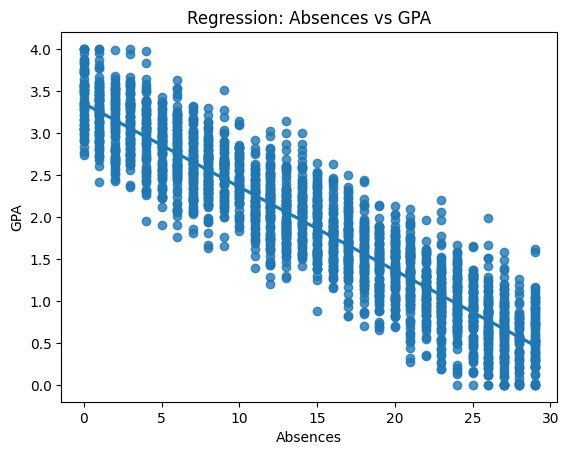

In [27]:
sns.regplot(x="Absences", y="GPA", data=df) # draws a linear regression line

plt.title("Regression: Absences vs GPA")
plt.xlabel("Absences")
plt.ylabel("GPA")

plt.show()

The graph even at a visual stage shows that the slope coefficient is not going to be zero.

In [28]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    GPA   R-squared:                       0.845
Model:                            OLS   Adj. R-squared:                  0.845
Method:                 Least Squares   F-statistic:                 1.304e+04
Date:                Tue, 03 Mar 2026   Prob (F-statistic):               0.00
Time:                        22:39:23   Log-Likelihood:                -950.72
No. Observations:                2392   AIC:                             1905.
Df Residuals:                    2390   BIC:                             1917.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.3510      0.015    228.914      0.0

We can interpret the OLS linear model summary the following way:

Rsquared implies that 84% of GPA can be explained by absences. At the same time the model is statistically significant thanks to p-value and f-value being zero. 

Absences coefficient (-0.094) shows that one absence leads to a 0.094 decrease in GPA.


MODEL CONCLUSIONS

Rsquared (0.84) raises the question as to why the majority of GPA is constructed by absences. Such a strong correlation makes it more difficult to arrive at decisions and conclusions since the data could be collected with the purpose of absences explaining GPA and have an omitted bias.

The dataset could even possibly be synthetic.

One other possible explanation for GPA to be constructed by absences is that absences are included in the calculation of student grades at this given school where the data comes from.

Now let's try to build a linear regression on x = Study Time Weekly and see if Rsquared shows any significant impact

In [29]:
X = df[["StudyTimeWeekly"]]
X = sm.add_constant(X)

y = df["GPA"]
model_1 = sm.OLS(y, X).fit()

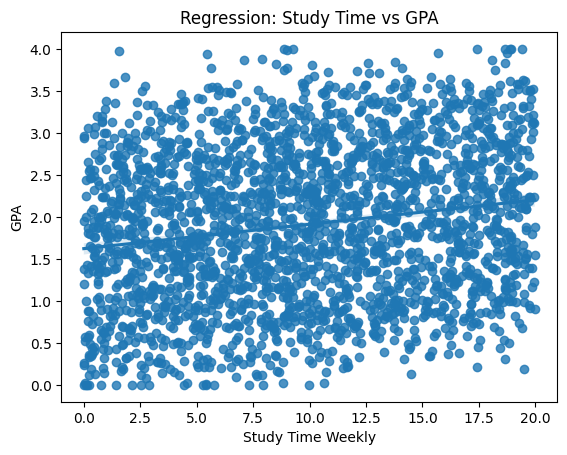

In [30]:
sns.regplot(x="StudyTimeWeekly", y="GPA", data=df) # draws a linear regression line

plt.title("Regression: Study Time vs GPA")
plt.xlabel("Study Time Weekly")
plt.ylabel("GPA")

plt.show()

In [31]:
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:                    GPA   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.032
Method:                 Least Squares   F-statistic:                     79.36
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           1.00e-18
Time:                        22:39:24   Log-Likelihood:                -3142.5
No. Observations:                2392   AIC:                             6289.
Df Residuals:                    2390   BIC:                             6300.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               1.6226      0.037     

And this model, while showing a way weaker correlation between independent and dependent variables (Rsquared = 0.032) which would equal to Study Time Weekly explaining only a 3% of GPA.

Study Time coefficient is 0.029 which means that every hour of study time brings a 0.029 increase on GPA - incredibly small. 

While the model seems significant (p-value = 0 and F-statistic value = 1.00e-18), the practical impact of Study Time on GPA appears limited relative to absences.

FOR POWER BI EXPORT

In [32]:

df.to_csv("Student_Performance_clean.csv", index=False)

df


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass,AgeGroup,GenderGroup
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0,17,Female
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0,18,Male
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0,15,Male
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0,17,Female
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0,17,Female
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2387,3388,18,1,0,3,10.680555,2,0,4,1,0,0,0,3.455509,0.0,18,Female
2388,3389,17,0,0,1,7.583217,4,1,4,0,1,0,0,3.279150,4.0,17,Male
2389,3390,16,1,0,2,6.805500,20,0,2,0,0,0,1,1.142333,2.0,16,Female
2390,3391,16,1,1,0,12.416653,17,0,2,0,1,1,0,1.803297,1.0,16,Female
